# MNIST Classifier - FeedForward(MLP) Neural Network


## Libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from random import random
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path
import librosa
import json
from collections import defaultdict
from torchvision.transforms import ToTensor
from torchvision import datasets
from torch.utils.data import Subset
from collections import defaultdict

## GPU


In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Device: {device}")

Device: mps


## Data


In [3]:
def download_mnist_datasets():
    train_data = datasets.MNIST(
        root="data", train=True, download=True, transform=ToTensor()
    )

    test_data = datasets.MNIST(
        root="data", train=False, download=True, transform=ToTensor()
    )

    return train_data, test_data


In [4]:
def create_dataset(valid_size):
    train_data, test_data = download_mnist_datasets()

    # Pass train_data.targets directly for stratified splitting
    train_indices, valid_indices = train_test_split(
        list(range(len(train_data))),
        test_size=valid_size,
        random_state=42,
        stratify=train_data.targets,
    )

    train_subset = Subset(train_data, train_indices)
    valid_subset = Subset(train_data, valid_indices)

    train_dataloader = DataLoader(train_subset, batch_size=32, shuffle=True)
    valid_dataloader = DataLoader(valid_subset, batch_size=32)
    test_dataloader = DataLoader(test_data, batch_size=32)

    # Return test_data as well for single-sample inference
    return train_dataloader, valid_dataloader, test_dataloader, test_data


In [5]:
train_dataloader, valid_dataloader, test_dataloader, test_dataset = create_dataset(0.2)

## PyTorch Feed-Forward Neural Network


In [6]:
class MNISTFeedForward(nn.Module):
    def __init__(self, num_classes=10, dropout_prob=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.net(x)


def evaluate(model, dataloader, loss_fn, device=torch.device("cpu")):
    model.to(device)
    model.eval()
    test_loss, test_correct, test_total = 0.0, 0, 0

    with torch.inference_mode():
        for x_batch, y_batch in dataloader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            preds = model(x_batch)
            loss = loss_fn(preds, y_batch)
            test_loss += loss.item() * x_batch.size(0)
            test_correct += (preds.argmax(1) == y_batch).sum().item()
            test_total += y_batch.size(0)

    avg_test_loss = test_loss / test_total
    avg_test_acc = test_correct / test_total

    return avg_test_loss, avg_test_acc


def train(
    model,
    train_loader,
    valid_loader,
    optimizer,
    loss_fn,
    epochs=10,
    device=torch.device("cpu"),
):
    history = defaultdict(list)
    model.to(device)

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0

        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)

            optimizer.zero_grad(set_to_none=True)
            preds = model(x_batch)
            loss = loss_fn(preds, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * x_batch.size(0)
            train_correct += (preds.argmax(1) == y_batch).sum().item()
            train_total += y_batch.size(0)

        # Evaluate on validation loader
        valid_loss, valid_acc = evaluate(model, valid_loader, loss_fn, device)

        avg_train_loss = train_loss / train_total
        train_acc = train_correct / train_total

        # Matching keys expected by plot_history()
        history["train_loss"].append(avg_train_loss)
        history["train_acc"].append(train_acc)
        history["valid_loss"].append(valid_loss)
        history["valid_acc"].append(valid_acc)

        print(
            f"Epoch {epoch + 1:3d}/{epochs} | "
            f"train_loss: {avg_train_loss:.4f} - train_acc: {train_acc:.4f} | "
            f"valid_loss: {valid_loss:.4f} - valid_acc: {valid_acc:.4f}"
        )

    print("========================")
    print("Training Finished!\n")
    return history


## Plot Results


In [7]:
def plot_history(history):
    fig, axs = plt.subplots(2, figsize=(10, 8))

    # create accuracy subplot
    axs[0].plot(history["train_acc"], label="train accuracy")
    axs[0].plot(history["valid_acc"], label="valid accuracy")
    axs[0].set_ylabel("Accuracy")
    axs[0].legend(loc="best")
    axs[0].set_title("Accuracy eval")

    # create error subplot
    axs[1].plot(history["train_loss"], label="train error")
    axs[1].plot(history["valid_loss"], label="valid error")
    axs[1].set_ylabel("Error")
    axs[1].set_xlabel("Epoch")
    axs[1].legend(loc="best")
    axs[1].set_title("Error eval")

    fig.tight_layout()
    plt.show()


## Testing


In [8]:
if __name__ == "__main__":
    model = MNISTFeedForward(num_classes=10, dropout_prob=0.3).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()

    model_history = train(
        model=model,
        train_loader=train_dataloader,
        valid_loader=valid_dataloader,
        optimizer=optimizer,
        loss_fn=loss_fn,
        epochs=10,
        device=device,
    )


Epoch   1/10 | train_loss: 0.3358 - train_acc: 0.8995 | valid_loss: 0.1392 - valid_acc: 0.9567
Epoch   2/10 | train_loss: 0.1561 - train_acc: 0.9536 | valid_loss: 0.1176 - valid_acc: 0.9651
Epoch   3/10 | train_loss: 0.1195 - train_acc: 0.9643 | valid_loss: 0.0968 - valid_acc: 0.9716
Epoch   4/10 | train_loss: 0.1005 - train_acc: 0.9694 | valid_loss: 0.0895 - valid_acc: 0.9725
Epoch   5/10 | train_loss: 0.0879 - train_acc: 0.9730 | valid_loss: 0.0827 - valid_acc: 0.9758
Epoch   6/10 | train_loss: 0.0763 - train_acc: 0.9757 | valid_loss: 0.0867 - valid_acc: 0.9768
Epoch   7/10 | train_loss: 0.0729 - train_acc: 0.9774 | valid_loss: 0.0820 - valid_acc: 0.9776
Epoch   8/10 | train_loss: 0.0644 - train_acc: 0.9793 | valid_loss: 0.0842 - valid_acc: 0.9769
Epoch   9/10 | train_loss: 0.0636 - train_acc: 0.9798 | valid_loss: 0.0863 - valid_acc: 0.9767
Epoch  10/10 | train_loss: 0.0622 - train_acc: 0.9806 | valid_loss: 0.0857 - valid_acc: 0.9772
Training Finished!



### Overfitting Debugging


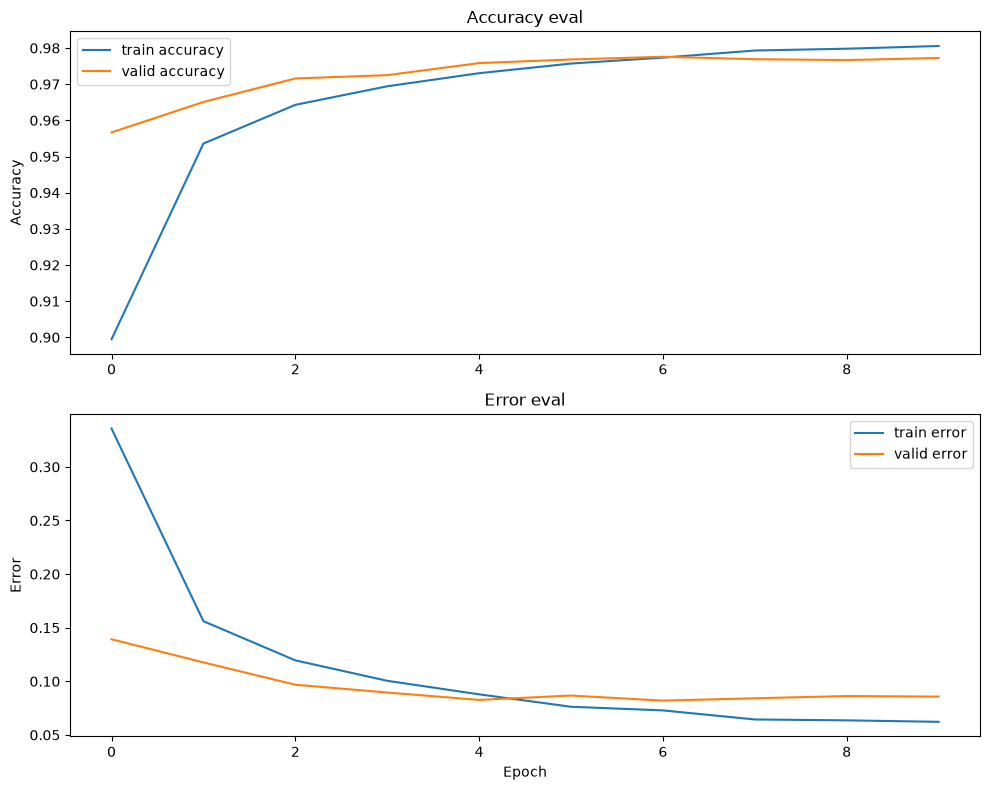

In [9]:
# plot accuracy and error over the epochs
plot_history(model_history)

### Evaluation Loss


In [10]:
test_loss, test_acc = evaluate(model, test_dataloader, loss_fn, device)
print(f"Final Test Loss: {test_loss:.4f} | Final Test Accuracy: {test_acc:.4f}")

Final Test Loss: 0.0753 | Final Test Accuracy: 0.9795


### Test Inference


In [11]:
def predict(model, X, y, mapping, device=torch.device("cpu")):
    X = X.unsqueeze(0).to(device)
    model.to(device)
    model.eval()

    with torch.inference_mode():
        logits = model(X)
        predicted_class = logits.argmax(1).item()

    # Handle y whether it is an int or a 0-dim tensor
    target_class = y.item() if isinstance(y, torch.Tensor) else y
    target_label = mapping[target_class]
    predicted_label = mapping[predicted_class]

    print(
        f"Prediction: {predicted_class} ({predicted_label}) | "
        f"Target: {target_class} ({target_label})"
    )


In [12]:
mapping = test_dataset.classes
X, y = test_dataset[100]
predict(model, X, y, mapping, device)


Prediction: 6 (6 - six) | Target: 6 (6 - six)
